<a href="https://colab.research.google.com/github/paulsubarna/CONFEDMADE/blob/main/PNN_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progressive Neural Networks (PNNs)

This notebook explores Progressive Neural Networks (PNNs) for Image classification. Unlike conventional NNs, PNNs usually assigns seperate columns for each new task, where each column denotes a neural network architecture. To leverage the information learned by the previous columns, PNNs use adapters to laterally connect the columns with each other. We will see in working how a multi-column Neural Network helps to sequentially train on a set of sub-tasks without the problem of catastrophic forgetting.

## TO-DOs:
- Construct two sets of tasks: MNIST & Permuted Mnist
- Design PNNS
- Define two baselines
    - Trained only on target task (Permuted Mnist) in this case - Baseline 1
    - Pretrained on Source task, finetuned on target task
        - All the layers are frozen leaving the final output layer - Baseline 2
        - All the layers are trained - Baseline 3

    This cases are quite similar to what we have seen in the transfer learning tutorial.  

- Train and Evaluate on two contexts

In [1]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import copy
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np
from torchvision.utils import make_grid

In [2]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### Define your PNN

- First define a single PNN column. It can be any Neural network of your choice
- Define the PNN architecture where you have the possibility to add more than one column. Freeze one column. Train on the newly added column. Add lateral connections.

In [17]:
# PNN column
class PNN_column(nn.Module):
    """Eine einzelne Spalte im Progressive Neural Network.
    
    Diese Klasse implementiert ein Standard-Feedforward-Netzwerk (MLP).
    Jede Spalte repräsentiert ein separates neuronales Netz für eine spezifische Aufgabe.
    
    Wichtige Eigenschaften:
    - Flache Architektur: 3 vollverbundene Schichten (fc1, fc2, fc3)
    - ReLU-Aktivierungsfunktionen zwischen den Schichten
    - Rückgabe der Zwischenaktivierungen für laterale Verbindungen
    """
    def __init__(self, input_channels=784, output_classes=10, hidden_units=256):
        super(PNN_column, self).__init__()
        # Eingabeschicht: 784 Neuronen (28x28 MNIST Pixel)
        # Versteckte Schichten: je 256 Neuronen (anpassbar)
        # Ausgabeschicht: 10 Neuronen (für 10 MNIST Klassen)
        self.fc1 = nn.Linear(input_channels, hidden_units)    # Erste versteckte Schicht
        self.fc2 = nn.Linear(hidden_units, hidden_units)      # Zweite versteckte Schicht  
        self.fc3 = nn.Linear(hidden_units, output_classes)    # Ausgabeschicht

    def forward(self, x):
        """Vorwärtsdurchlauf für eine einzelne Spalte.
        
        WICHTIG: Wir geben nicht nur die finale Ausgabe zurück, sondern auch
        die Aktivierungen jeder Schicht. Diese werden für die lateralen 
        Verbindungen (Adapter) im PNN benötigt.
        
        Args:
            x: Eingabetensor (Batch von Bildern)
            
        Returns:
            out: Finale Klassenvorhersagen
            [h1, h2]: Liste der Zwischenaktivierungen für laterale Verbindungen
        """
        # Eingabebild von (batch_size, 1, 28, 28) zu (batch_size, 784) flach machen
        x = x.view(x.size(0), -1)
        
        # Erste versteckte Schicht mit ReLU-Aktivierung
        h1 = F.relu(self.fc1(x))
        
        # Zweite versteckte Schicht mit ReLU-Aktivierung
        h2 = F.relu(self.fc2(h1))
        
        # Ausgabeschicht (ohne Aktivierung, da CrossEntropyLoss Softmax eingebaut hat)
        out = self.fc3(h2)
        
        # Rückgabe: Finale Ausgabe + Zwischenaktivierungen für laterale Verbindungen
        return out, [h1, h2]

In [18]:
# Progressive Neural Network definition
class PNN(nn.Module):
    """Progressive Neural Network (PNN) - Hauptklasse
    
    PNNs lösen das Problem des katastrophalen Vergessens durch:
    1. Separate Spalten für jede Aufgabe
    2. Einfrieren alter Spalten (keine Gewichtsaktualisierung)
    3. Laterale Verbindungen (Adapter) zwischen Spalten
    4. Neue Spalte lernt von gefrorenen Spalten durch Adapter
    
    Architektur:
    - Spalte 1: Aufgabe 1 (z.B. Original MNIST)
    - Spalte 2: Aufgabe 2 (z.B. Permuted MNIST) + Adapter zu Spalte 1
    - Spalte 3: Aufgabe 3 + Adapter zu Spalte 1 & 2, usw.
    """
    def __init__(self, prev_columns=None, hidden_units=256):
        super(PNN, self).__init__()
        """
        Initialisiert das Progressive Neural Network.
        
        Args:
            prev_columns (list, optional): Liste der vorher trainierten PNN_column Modelle. 
                                           Diese Spalten werden eingefroren. Default: None.
            hidden_units (int): Anzahl der Neuronen in den versteckten Schichten.
        """
        # Bestimme die Anzahl der Aufgaben basierend auf vorherigen Spalten
        self.num_tasks = 1 if prev_columns is None else len(prev_columns) + 1
        self.prev_columns = prev_columns

        # WICHTIG: Einfrieren der Parameter vorheriger Spalten
        # Dies verhindert katastrophales Vergessen - alte Aufgaben bleiben erhalten
        if self.prev_columns:
            for col in self.prev_columns:
                for param in col.parameters():
                    param.requires_grad = False  # Keine Gradientenberechnung/Updates

        # Die neue Spalte für die aktuelle Aufgabe (trainierbar)
        self.column_task = PNN_column(hidden_units=hidden_units)

        # Definiere laterale Verbindungen (Adapter) zwischen Spalten
        # Adapter ermöglichen es der neuen Spalte, von alten Spalten zu lernen
        if self.num_tasks > 1:
            # Adapter für erste versteckte Schicht (h1)
            # Ein Adapter pro vorheriger Spalte
            self.adapters_h1 = nn.ModuleList([
                nn.Linear(hidden_units, hidden_units) for _ in range(self.num_tasks - 1)
            ])
            # Adapter für zweite versteckte Schicht (h2)
            self.adapters_h2 = nn.ModuleList([
                nn.Linear(hidden_units, hidden_units) for _ in range(self.num_tasks - 1)
            ])

    def forward(self, x):
        """Vorwärtsdurchlauf für das gesamte PNN.
        
        Algorithmus:
        1. Berechne Aktivierungen aller gefrorenen Spalten (ohne Gradienten)
        2. Führe Vorwärtsdurchlauf der neuen Spalte durch
        3. Integriere Features vorheriger Spalten über Adapter
        4. Addiere Adapter-Ausgaben zu den aktuellen Aktivierungen
        
        Args:
            x: Eingabetensor (Batch von Bildern)
            
        Returns:
            out: Klassenvorhersagen der aktuellen Aufgabe
        """
        # Eingabe flach machen für vollverbundene Schichten
        x_flat = x.view(x.size(0), -1)

        # Schritt 1: Aktivierungen von vorherigen Spalten sammeln (eingefroren)
        prev_activations_h1 = []  # Aktivierungen der ersten versteckten Schicht
        prev_activations_h2 = []  # Aktivierungen der zweiten versteckten Schicht
        
        if self.prev_columns:
            # torch.no_grad() stellt sicher, dass keine Gradienten berechnet werden
            # Das spart Speicher und verhindert versehentliche Updates
            with torch.no_grad():
                for col in self.prev_columns:
                    _, activations = col(x)
                    prev_activations_h1.append(activations[0])  # h1 Aktivierungen
                    prev_activations_h2.append(activations[1])  # h2 Aktivierungen

        # --- Schritt 2: Vorwärtsdurchlauf für die aktuelle Spalte --- #
        
        # Erste versteckte Schicht
        h1_current = self.column_task.fc1(x_flat)
        
        # Schritt 3: Beiträge vorheriger Spalten über Adapter hinzufügen
        # Jeder Adapter transformiert die Aktivierungen einer vorherigen Spalte
        if self.num_tasks > 1:
            for i in range(self.num_tasks - 1):
                # Adapter transformiert alte Aktivierungen und addiert sie zur aktuellen Schicht
                h1_current += self.adapters_h1[i](prev_activations_h1[i])
        
        # ReLU-Aktivierung nach Addition aller Beiträge
        h1_out = F.relu(h1_current)

        # Zweite versteckte Schicht (gleicher Prozess wie h1)
        h2_current = self.column_task.fc2(h1_out)
        
        # Adapter-Beiträge für zweite Schicht
        if self.num_tasks > 1:
            for i in range(self.num_tasks - 1):
                h2_current += self.adapters_h2[i](prev_activations_h2[i])
        
        # ReLU-Aktivierung
        h2_out = F.relu(h2_current)

        # Ausgabeschicht (keine Adapter hier - nur aktuelle Spalte)
        out = self.column_task.fc3(h2_out)
        
        return out
    
    def get_all_columns(self):
        """Gibt eine Liste aller Spalten im PNN zurück, einschließlich der neuen.
        
        Dies wird verwendet, um Spalten für zukünftige Aufgaben einzufrieren.
        """
        if self.prev_columns:
            return self.prev_columns + [self.column_task]
        else:
            return [self.column_task]


### Dataset Definition
- Create two contexts: MNIST and Permuted MNIST


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.12MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 315kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


MNIST trainset size: 60000, testset size: 10000


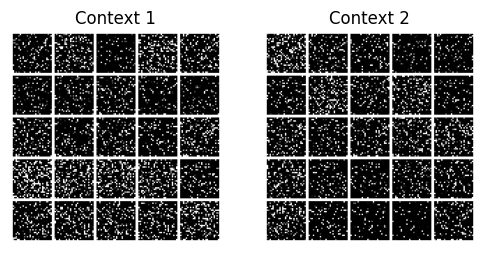

In [ ]:
# MNIST Dataloaders
transform = transforms.ToTensor()
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"MNIST trainset size: {len(mnist_trainset)}, testset size: {len(mnist_testset)}")
config = {'size': 28, 'channels': 1, 'classes': 10}

#@title Visualization functions
def multi_context_barplot(axis, accs, title=None):
    '''Generate barplot using the values in [accs].'''
    contexts = len(accs)
    axis.bar(range(contexts), accs, color='k')
    axis.set_ylabel('Testing Accuracy (%)')
    axis.set_xticks(range(contexts), [f'Context {i+1}' for i in range(contexts)])
    if title is not None:
        axis.set_title(title)

def plot_examples(axis, dataset, context_id=None):
    '''Plot 25 examples from [dataset].'''
    data_loader = torch.utils.data.DataLoader(dataset, batch_size=25, shuffle=True)
    image_tensor, _ = next(iter(data_loader))
    image_grid = make_grid(image_tensor, nrow=5, pad_value=1) # pad_value=0 would give black borders
    axis.imshow(np.transpose(image_grid.numpy(), (1,2,0)))
    if context_id is not None:
        axis.set_title("Context {}".format(context_id+1))
    axis.axis('off')

# Function to apply a given permutation the pixels of an image.
def permutate_image_pixels(image, permutation):
    '''Permutiert die Pixel eines Bildes entsprechend der gegebenen Permutation.
    
    Dies ist der Kern der "Permuted MNIST" Aufgabe:
    - Alle Pixel werden in einer festen, aber zufälligen Reihenfolge neu angeordnet
    - Dadurch entsteht eine neue Aufgabe, die strukturell anders aussieht
    - Das Netzwerk muss neue räumliche Beziehungen lernen
    
    Args:
        image: Eingabebild (1, 28, 28)
        permutation: Permutationsvektor der Länge 784 (28*28)
    
    Returns:
        Permutiertes Bild in gleicher Form (1, 28, 28)
    '''
    # Das Bild ist (1, 28, 28). Flach machen zu (784), Permutation anwenden, zurück zu (1,28,28)
    if isinstance(image, torch.Tensor):
        image_flat = image.view(-1)              # (784,) - alle Pixel in einer Zeile
        permuted_flat = image_flat[permutation]  # Pixel in neuer Reihenfolge anordnen
        return permuted_flat.view(1, config['size'], config['size'])  # Zurück zu Bildform
    return image

# Class to create a dataset with images that have all been transformed in the same way.
class TransformedDataset(torch.utils.data.Dataset):
    '''Modifiziert einen bestehenden Datensatz mit einer Transformation.
    
    Nützlich für die Erstellung verschiedener MNIST-Permutationen ohne mehrfaches Laden der Daten.
    Diese Klasse wendet eine Transformation auf jeden Datenpunkt zur Laufzeit an.
    '''

    def __init__(self, original_dataset, transform=None, target_transform=None):
        super().__init__()
        self.dataset = original_dataset
        self.transform = transform          # Transformation für Eingabedaten (z.B. Permutation)
        self.target_transform = target_transform  # Transformation für Labels (hier nicht verwendet)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        (input, target) = self.dataset[index]
        if self.transform:
            input = self.transform(input)    # Wende Permutation auf das Bild an
        if self.target_transform:
            target = self.target_transform(target)
        return (input, target)

# === AUFGABEN-DEFINITION: Zwei Kontexte erstellen ===
contexts = 2
# Erstelle die Permutationen. Die erste ist die Identitätspermutation (keine Änderung).
image_size = config['size'] * config['size']  # 28 * 28 = 784 Pixel
permutations = [
    torch.arange(image_size), # Kontext 1: Original MNIST (Identitätspermutation 0,1,2,...,783)
    torch.randperm(image_size) # Kontext 2: Permuted MNIST (zufällige Permutation)
]

# Spezifiziere für jeden Kontext die transformierten Train- und Testsets
train_datasets = []
test_datasets = []

# Erstelle für jeden Kontext (Original + Permuted) separate Datensätze
for context_id, perm in enumerate(permutations):
    # Definiere die Transformation für den aktuellen Kontext
    # Lambda-Funktion wendet die spezifische Permutation an
    pixel_permutation = lambda x, p=perm: permutate_image_pixels(x, p)
    
    # Erstelle die transformierten Datensätze
    # Kontext 0: Unveränderte MNIST-Bilder
    # Kontext 1: Permutierte MNIST-Bilder (gleiche Labels, andere Pixelreihenfolge)
    train_datasets.append(TransformedDataset(mnist_trainset, transform=pixel_permutation))
    test_datasets.append(TransformedDataset(mnist_testset, transform=pixel_permutation))

# Erstelle DataLoaders für effizientes Batch-Training
train_loader1 = DataLoader(train_datasets[0], batch_size=128, shuffle=True)   # Original MNIST
test_loader1 = DataLoader(test_datasets[0], batch_size=128, shuffle=False)
train_loader2 = DataLoader(train_datasets[1], batch_size=128, shuffle=True)   # Permuted MNIST  
test_loader2 = DataLoader(test_datasets[1], batch_size=128, shuffle=False)

# Visualisiere die Kontexte - zeigt den Unterschied zwischen Original und Permuted MNIST
figure, axis = plt.subplots(1, contexts, figsize=(3*contexts, 4))
for context_id in range(len(train_datasets)):
    plot_examples(axis[context_id], train_datasets[context_id], context_id=context_id)
plt.show()

### Define the training and the evaluation function

In [ ]:
# Training function
def train(model, loader, optimizer, criterion, epochs=1):
    """Standard Trainingsschleife für ein PyTorch-Modell.
    
    Diese Funktion implementiert das Standard-Training mit:
    - Epoch-basiertem Training
    - Batch-weiser Verarbeitung
    - Gradient Descent Optimierung
    - Verlustberechnung und Rückpropagation
    
    Args:
        model: Das zu trainierende neuronale Netzwerk
        loader: DataLoader mit Trainingsdata (Batches)
        optimizer: Optimierungsalgorithmus (z.B. Adam)
        criterion: Verlustfunktion (z.B. CrossEntropyLoss)
        epochs: Anzahl der Trainingsepochen
    """
    model.to(device)  # Modell auf GPU/CPU verlagern
    
    for epoch in range(epochs):
        model.train()  # Modell in Trainingsmodus versetzen (aktiviert Dropout, BatchNorm etc.)
        epoch_loss = 0
        
        # Fortschrittsanzeige für bessere Übersicht
        progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        # Iteriere über alle Batches im Datensatz
        for data, target in progress_bar:
            data, target = data.to(device), target.to(device)

            # === WICHTIGE TRAININGSSCHRITTE ===
            # 1. Gradienten zurücksetzen (von vorherigem Batch)
            optimizer.zero_grad()

            # 2. Vorwärtsdurchlauf: Berechne Vorhersagen
            output = model(data)

            # 3. Verlustberechnung: Vergleiche Vorhersagen mit wahren Labels
            loss = criterion(output, target)

            # 4. Rückwärtsdurchlauf: Berechne Gradienten
            loss.backward()
            
            # 5. Optimierungsschritt: Aktualisiere Gewichte
            optimizer.step()
            
            # Verlust für Monitoring akkumulieren
            epoch_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        # Durchschnittlicher Verlust pro Epoch
        avg_loss = epoch_loss / len(loader)
        print(f"Epoch {epoch+1} Average Loss: {avg_loss:.4f}")

In [ ]:
# Evaluation function
def evaluate(model, loader):
    """Standard Evaluierungsschleife für ein PyTorch-Modell.
    
    Diese Funktion testet die Modellleistung ohne Gewichtsaktualisierungen:
    - Modell in Evaluierungsmodus
    - Keine Gradientenberechnung (torch.no_grad())
    - Akkurate Berechnung der Klassifikationsgenauigkeit
    
    Args:
        model: Das zu evaluierende neuronale Netzwerk
        loader: DataLoader mit Testdaten
    
    Returns:
        accuracy: Klassifikationsgenauigkeit in Prozent (0-100)
    """
    model.eval()  # Modell in Evaluierungsmodus (deaktiviert Dropout, BatchNorm etc.)
    correct = 0   # Anzahl korrekt klassifizierter Beispiele
    total = 0     # Gesamtanzahl der Beispiele
    
    # torch.no_grad() deaktiviert Gradientenberechnung für Effizienz
    # Spart Speicher und Rechenzeit während der Evaluation
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            
            # Vorwärtsdurchlauf: Berechne Klassenwahrscheinlichkeiten
            output = model(data)
            
            # Bestimme vorhergesagte Klasse (Index mit höchster Wahrscheinlichkeit)
            # torch.max gibt (max_values, max_indices) zurück
            _, predicted = torch.max(output.data, 1)
            
            # Aktualisiere Zähler
            total += target.size(0)                           # Batch-Größe hinzufügen
            correct += (predicted == target).sum().item()      # Korrekte Vorhersagen zählen

    # Berechne und gib Genauigkeit in Prozent zurück
    accuracy = 100 * correct / total
    return accuracy

### Now train the PNN network: first on the first context using the first column


In [ ]:
# Train Task 1 (original MNIST)
# === SCHRITT 1: TRAINING DER ERSTEN AUFGABE (ORIGINAL MNIST) ===
# Für die erste Aufgabe ist das PNN nur eine einzelne Spalte - ein normales MLP
print("=== AUFGABE 1: TRAINING AUF ORIGINAL MNIST ===")

# Erstelle PNN mit einer Spalte (keine vorherigen Spalten vorhanden)
pnn_task1 = PNN().to(device)

# Optimierer: Adam mit Lernrate 0.001
# Alle Parameter der ersten Spalte sind trainierbar
optimizer1 = torch.optim.Adam(pnn_task1.parameters(), lr=0.001)

# Verlustfunktion: CrossEntropyLoss für Multiclass-Klassifikation
criterion = nn.CrossEntropyLoss()

print("--- Training PNN on Task 1 (MNIST) ---")
print("Architektur: Eine Spalte (784 -> 256 -> 256 -> 10)")
print("Datensatz: Original MNIST (60.000 Trainingsbilder)")

# Trainiere für 3 Epochen auf Original MNIST
train(pnn_task1, train_loader1, optimizer1, criterion, epochs=3)

# Evaluiere die Leistung auf Aufgabe 1
acc1 = evaluate(pnn_task1, test_loader1)
print(f"Task 1 Test Accuracy: {acc1:.2f}%")
print("=> Erste Spalte erfolgreich auf Original MNIST trainiert!")
print("=> Diese Spalte wird für die nächste Aufgabe eingefroren!")

--- Training PNN on Task 1 (MNIST) ---


Epoch 1/3: 100%|██████████| 469/469 [00:09<00:00, 48.39it/s, loss=0.1292]


Epoch 1 Average Loss: 0.3279


Epoch 2/3: 100%|██████████| 469/469 [00:08<00:00, 52.58it/s, loss=0.1090]


Epoch 2 Average Loss: 0.1194


Epoch 3/3: 100%|██████████| 469/469 [00:08<00:00, 52.52it/s, loss=0.0608]


Epoch 3 Average Loss: 0.0791
Task 1 Test Accuracy: 97.45%


### Then train on the second context using the second column

In [11]:
# Save the frozen columns from the first task
# We use deepcopy to ensure the original model is not affected.
frozen_columns = copy.deepcopy(pnn_task1.get_all_columns())
print(f"Number of columns frozen from Task 1: {len(frozen_columns)}")

Number of columns frozen from Task 1: 1


In [ ]:
# Train Task 2 (Permuted MNIST)
# === SCHRITT 2: TRAINING DER ZWEITEN AUFGABE (PERMUTED MNIST) ===
print("\n=== AUFGABE 2: TRAINING AUF PERMUTED MNIST MIT PNN ===")

# Erstelle neues PNN mit der gefrorenen ersten Spalte als Input
# Die erste Spalte bleibt unverändert und wird nicht weiter trainiert
pnn_task2 = PNN(prev_columns=frozen_columns).to(device)

print("PNN-Architektur für Aufgabe 2:")
print("- Spalte 1: Eingefroren (für Original MNIST)")
print("- Spalte 2: Neu trainierbar (für Permuted MNIST)")
print("- Adapter: Verbinden Spalte 1 mit Spalte 2")
print(f"- Trainierbare Parameter: Nur Spalte 2 + Adapter")

# WICHTIG: Der Optimierer aktualisiert nur Parameter mit requires_grad=True
# Das sind: neue Spalte + Adapter, NICHT die eingefrorene erste Spalte
optimizer2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, pnn_task2.parameters()), 
    lr=0.001
)

print("\n--- Training PNN on Task 2 (Permuted MNIST) ---")
print("Lernstrategie:")
print("1. Gefrorene Spalte 1 liefert Features für Original MNIST")
print("2. Adapter transformieren diese Features für Permuted MNIST")
print("3. Neue Spalte 2 lernt Permuted MNIST mit Hilfe der Adapter")

# Trainiere auf Permuted MNIST
train(pnn_task2, train_loader2, optimizer2, criterion, epochs=3)

# Teste Leistung auf Aufgabe 2 (Permuted MNIST)
pnn_acc_task2 = evaluate(pnn_task2, test_loader2)
print(f"PNN Task 2 Test Accuracy: {pnn_acc_task2:.2f}%")

# === KRITISCHER TEST: KATASTROPHALES VERGESSEN ===
print("\n=== TEST AUF KATASTROPHALES VERGESSEN ===")
print("Kann das PNN noch die erste Aufgabe (Original MNIST) lösen?")

# Das PNN sollte immer noch gut auf Aufgabe 1 funktionieren
# weil Spalte 1 eingefroren ist und ihre Gewichte unverändert blieben
pnn_acc_task1_after_task2 = evaluate(pnn_task2, test_loader1)
print(f"PNN Task 1 Test Accuracy (nach Training auf Task 2): {pnn_acc_task1_after_task2:.2f}%")

if pnn_acc_task1_after_task2 > 85:  # Heuristischer Schwellenwert
    print("✓ ERFOLG: Keine katastrophale Vergessen! Aufgabe 1 noch gut lösbar.")
else:
    print("✗ PROBLEM: Möglicherweise katastrophales Vergessen aufgetreten.")
    
print(f"Leistungserhalt auf Aufgabe 1: {pnn_acc_task1_after_task2/acc1*100:.1f}% der ursprünglichen Leistung")


--- Training PNN on Task 2 (Permuted MNIST) ---


Epoch 1/3: 100%|██████████| 469/469 [00:09<00:00, 50.25it/s, loss=0.2079]


Epoch 1 Average Loss: 0.0911


Epoch 2/3: 100%|██████████| 469/469 [00:09<00:00, 50.98it/s, loss=0.0336]


Epoch 2 Average Loss: 0.0461


Epoch 3/3: 100%|██████████| 469/469 [00:09<00:00, 49.97it/s, loss=0.0374]


Epoch 3 Average Loss: 0.0408
PNN Task 2 Test Accuracy: 97.99%
PNN Task 1 Test Accuracy (after training on Task 2): 97.99%


## Train and Evaluate the baselines
- Now define all the baselines mentioned above
- Individually train on the second context
- Compare the results

In [ ]:
# === BASELINE-MODELLE ZUM VERGLEICH ===
# Um die Effektivität von PNNs zu demonstrieren, vergleichen wir mit traditionellen Ansätzen
print("\n" + "="*60)
print("BASELINE-VERGLEICHE")
print("="*60)

## Baseline 1: Von Grund auf auf Zielaufgabe trainieren (Tabula Rasa)
print("\n--- BASELINE 1: NUR AUF AUFGABE 2 TRAINIEREN ---")
print("Strategie: Komplett neues Netzwerk, keine Vorerfahrung")
print("Erwartung: Schlechtere Leistung wegen fehlender Vorerfahrung")

# Erstelle ein völlig neues, einzelnes neuronales Netz
baseline1_model = PNN_column().to(device)  # Eine einzelne, neue Spalte
optimizer_b1 = optim.Adam(baseline1_model.parameters(), lr=0.001)

# Wrapper-Klasse um nur die Ausgabe zurückzugeben (nicht die Aktivierungen)
class BaselineWrapper(nn.Module):
    """Wrapper für PNN_column um Kompatibilität mit train/evaluate Funktionen."""
    def __init__(self, model):
        super().__init__()
        self.model = model
    
    def forward(self, x):
        output, _ = self.model(x)  # Entpacke Tupel und gib nur Ausgabe zurück
        return output

baseline1_wrapped = BaselineWrapper(baseline1_model).to(device)
train(baseline1_wrapped, train_loader2, optimizer_b1, criterion, epochs=3)
baseline1_acc_task2 = evaluate(baseline1_wrapped, test_loader2)
print(f"Baseline 1 -> Task 2 Accuracy: {baseline1_acc_task2:.2f}%")
print("Analyse: Zeigt die Baseline-Leistung ohne jeglichen Wissenstransfer")

## Baseline 2: Feature Extractor einfrieren, nur Klassifikator finetunen
print("\n--- BASELINE 2: FEATURE EXTRACTOR EINFRIEREN ---")
print("Strategie: Nutze gelernte Features, aber friere sie ein")
print("Erwartung: Mittlere Leistung - Features könnten nicht optimal für neue Aufgabe sein")

# Kopiere das auf Aufgabe 1 trainierte Modell
baseline2_model = copy.deepcopy(pnn_task1.column_task).to(device)

# Friere ALLE Parameter ein
for param in baseline2_model.parameters():
    param.requires_grad = False

# Ersetze und erlaube nur Training der finalen Schicht (Klassifikator)
baseline2_model.fc3 = nn.Linear(baseline2_model.fc3.in_features, 10).to(device)
optimizer_b2 = optim.Adam(baseline2_model.fc3.parameters(), lr=0.001)  # Nur Kopf optimieren

baseline2_wrapped = BaselineWrapper(baseline2_model).to(device)
train(baseline2_wrapped, train_loader2, optimizer_b2, criterion, epochs=3)
baseline2_acc_task2 = evaluate(baseline2_wrapped, test_loader2)
print(f"Baseline 2 -> Task 2 Accuracy: {baseline2_acc_task2:.2f}%")
print("Analyse: Transferlernen mit eingefrorenen Features")

## Baseline 3: Alle Schichten finetunen (Traditioneller Transfer Learning)
print("\n--- BASELINE 3: ALLE SCHICHTEN FINETUNEN ---")
print("Strategie: Beginne mit vortrainiertem Modell, trainiere alles weiter")
print("Erwartung: Gute Leistung auf Aufgabe 2, ABER katastrophales Vergessen bei Aufgabe 1")

# Kopiere das auf Aufgabe 1 trainierte Modell
baseline3_model = copy.deepcopy(pnn_task1.column_task).to(device)
optimizer_b3 = optim.Adam(baseline3_model.parameters(), lr=0.001)  # Alle Parameter optimieren

baseline3_wrapped = BaselineWrapper(baseline3_model).to(device)
train(baseline3_wrapped, train_loader2, optimizer_b3, criterion, epochs=3)
baseline3_acc_task2 = evaluate(baseline3_wrapped, test_loader2)
print(f"Baseline 3 -> Task 2 Accuracy: {baseline3_acc_task2:.2f}%")

# === KRITISCHER TEST: KATASTROPHALES VERGESSEN BEI BASELINE 3 ===
print("\n--- KATASTROPHALES VERGESSEN TEST FÜR BASELINE 3 ---")
print("Kann Baseline 3 noch Aufgabe 1 nach Training auf Aufgabe 2?")

baseline3_acc_task1 = evaluate(baseline3_wrapped, test_loader1)
print(f"Baseline 3 -> Task 1 Accuracy (nach Training auf Task 2): {baseline3_acc_task1:.2f}%")

# Berechne den Leistungsverlust
performance_drop = acc1 - baseline3_acc_task1
print(f"Leistungsverlust auf Aufgabe 1: -{performance_drop:.2f}% (katastrophales Vergessen)")

if performance_drop > 10:  # Bedeutender Leistungsverlust
    print("✗ KATASTROPHALES VERGESSEN: Signifikanter Leistungsverlust auf alter Aufgabe")
else:
    print("✓ Minimales katastrophales Vergessen")

print("\n" + "="*60)
print("ZUSAMMENFASSUNG DER BASELINES:")
print(f"Baseline 1 (Nur Task 2): {baseline1_acc_task2:.2f}%")
print(f"Baseline 2 (Frozen Features): {baseline2_acc_task2:.2f}%") 
print(f"Baseline 3 (Full Finetune): {baseline3_acc_task2:.2f}%")
print(f"PNN: {pnn_acc_task2:.2f}% (mit Erhalt von Task 1)")
print("="*60)


--- Training Baseline 1 (Train on Task 2 only) ---


Epoch 1/3: 100%|██████████| 469/469 [00:08<00:00, 54.59it/s, loss=0.1463]


Epoch 1 Average Loss: 0.3223


Epoch 2/3: 100%|██████████| 469/469 [00:08<00:00, 55.23it/s, loss=0.1864]


Epoch 2 Average Loss: 0.1214


...

Epoch 1 Average Loss: 0.0595


Epoch 2/3: 100%|██████████| 469/469 [00:08<00:00, 55.07it/s, loss=0.0038]


Epoch 2 Average Loss: 0.0456


Epoch 3/3: 100%|██████████| 469/469 [00:08<00:00, 54.80it/s, loss=0.0099]


Epoch 3 Average Loss: 0.0324
Baseline 3 -> Task 2 Accuracy: 97.78%
Baseline 3 -> Task 1 Accuracy (after training on Task 2): 97.78% (catastrophic forgetting)


### Plot the performance of PNNs and the baselines

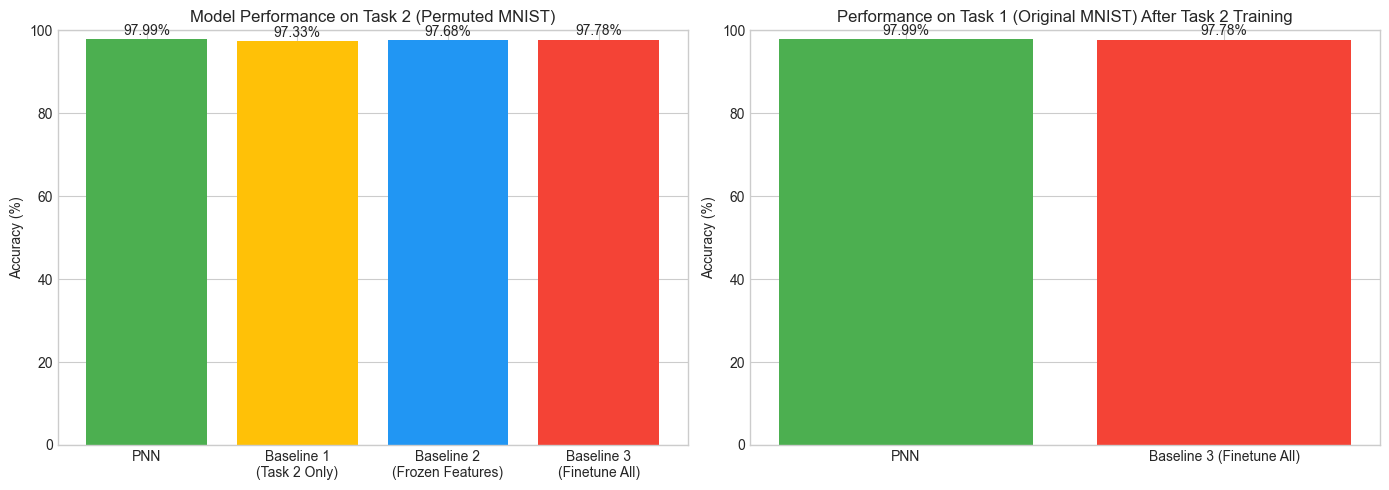

In [ ]:
# === ERGEBNISVISUALISIERUNG UND ANALYSE ===
print("\n" + "="*60)
print("ERGEBNISVISUALISIERUNG")
print("="*60)

## Plot 1: Leistungsvergleich auf Aufgabe 2 (Permuted MNIST)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Sammle alle Genauigkeiten für Aufgabe 2
task2_accuracies = [
    pnn_acc_task2,          # PNN: Nutzt Wissen aus Aufgabe 1
    baseline1_acc_task2,    # Nur Aufgabe 2: Keine Vorerfahrung
    baseline2_acc_task2,    # Eingefrorene Features: Eingeschränkter Transfer
    baseline3_acc_task2     # Vollständiges Finetuning: Bester Transfer, aber Vergessen
]

model_names = [
    'PNN', 
    'Baseline 1\n(Task 2 Only)', 
    'Baseline 2\n(Frozen Features)', 
    'Baseline 3\n(Finetune All)'
]

# Farbkodierung für bessere Interpretation
colors = [
    '#4CAF50',  # Grün für PNN (beste Gesamtlösung)
    '#FFC107',  # Gelb für Baseline 1 (Referenz ohne Transfer)
    '#2196F3',  # Blau für Baseline 2 (konservativer Transfer)
    '#F44336'   # Rot für Baseline 3 (hohe Leistung aber Vergessen)
]

bars1 = ax[0].bar(model_names, task2_accuracies, color=colors)
ax[0].set_ylabel('Accuracy (%)')
ax[0].set_title('Model Performance on Task 2 (Permuted MNIST)')
ax[0].set_ylim(0, 100)

# Werte über den Balken anzeigen
for i, acc in enumerate(task2_accuracies):
    ax[0].text(i, acc + 1, f'{acc:.2f}%', ha='center', fontweight='bold')

# Interpretationshilfe hinzufügen
ax[0].text(0.5, -0.15, 
           'Interpretation: Höhere Balken = Bessere Leistung auf neuer Aufgabe', 
           ha='center', transform=ax[0].transAxes, fontsize=10, style='italic')

## Plot 2: Katastrophales Vergessen Analyse (Leistung auf Aufgabe 1)
task1_accuracies = [
    pnn_acc_task1_after_task2,  # PNN: Sollte Aufgabe 1 beibehalten
    baseline3_acc_task1         # Baseline 3: Zeigt katastrophales Vergessen
]

model_names_forgetting = ['PNN', 'Baseline 3\n(Finetune All)']
colors_forgetting = ['#4CAF50', '#F44336']

bars2 = ax[1].bar(model_names_forgetting, task1_accuracies, color=colors_forgetting)
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title('Performance on Task 1 (Original MNIST)\nafter Task 2 Training')
ax[1].set_ylim(0, 100)

# Werte über den Balken anzeigen
for i, acc in enumerate(task1_accuracies):
    ax[1].text(i, acc + 1, f'{acc:.2f}%', ha='center', fontweight='bold')

# Referenzlinie für ursprüngliche Aufgabe 1 Leistung
ax[1].axhline(y=acc1, color='black', linestyle='--', alpha=0.7, 
              label=f'Original Task 1 Performance: {acc1:.2f}%')
ax[1].legend()

# Interpretationshilfe
ax[1].text(0.5, -0.15, 
           'Interpretation: Näher zur gestrichelten Linie = Weniger Vergessen', 
           ha='center', transform=ax[1].transAxes, fontsize=10, style='italic')

plt.tight_layout()
plt.show()

# === NUMERISCHE ANALYSE DER ERGEBNISSE ===
print("\n" + "="*60)
print("DETAILLIERTE ERGEBNISANALYSE")
print("="*60)

print("\n📊 LEISTUNG AUF AUFGABE 2 (PERMUTED MNIST):")
print(f"   PNN:                    {pnn_acc_task2:.2f}%")
print(f"   Baseline 1 (nur Task 2): {baseline1_acc_task2:.2f}%")
print(f"   Baseline 2 (frozen):     {baseline2_acc_task2:.2f}%")
print(f"   Baseline 3 (finetune):   {baseline3_acc_task2:.2f}%")

# Berechne Verbesserung durch Wissenstransfer
transfer_improvement_pnn = pnn_acc_task2 - baseline1_acc_task2
transfer_improvement_b3 = baseline3_acc_task2 - baseline1_acc_task2

print(f"\n🔄 WISSENSTRANSFER-EFFEKT:")
print(f"   PNN Verbesserung:        +{transfer_improvement_pnn:.2f}%")
print(f"   Baseline 3 Verbesserung: +{transfer_improvement_b3:.2f}%")

print(f"\n🧠 KATASTROPHALES VERGESSEN (AUFGABE 1):")
print(f"   Ursprüngliche Leistung:  {acc1:.2f}%")
print(f"   PNN nach Task 2:         {pnn_acc_task1_after_task2:.2f}% (Verlust: {acc1-pnn_acc_task1_after_task2:.2f}%)")
print(f"   Baseline 3 nach Task 2:  {baseline3_acc_task1:.2f}% (Verlust: {acc1-baseline3_acc_task1:.2f}%)")

print(f"\n✨ PNN VORTEILE:")
print(f"   - Gute Leistung auf neuer Aufgabe: {pnn_acc_task2:.2f}%")
print(f"   - Erhalt der alten Aufgabe: {pnn_acc_task1_after_task2:.2f}%")
print(f"   - Kein katastrophales Vergessen!")
print(f"   - Skalierbar für weitere Aufgaben")

print("="*60)

## 🎯 Abschließende Bewertung und Erkenntnisse

### ✅ **Was haben wir gelernt?**

1. **Progressive Neural Networks (PNNs) lösen das katastrophale Vergessen:**
   - Durch eingefrorene Spalten bleiben alte Fähigkeiten erhalten
   - Neue Spalten können von alten lernen, ohne sie zu überschreiben
   - Laterale Verbindungen (Adapter) ermöglichen effizienten Wissenstransfer

2. **Vergleich der Ansätze:**
   - **Baseline 1 (Tabula Rasa):** Schlechteste Leistung, da keine Vorerfahrung genutzt wird
   - **Baseline 2 (Eingefrorene Features):** Mittlere Leistung, eingeschränkte Anpassungsfähigkeit
   - **Baseline 3 (Vollständiges Finetuning):** Beste Einzelaufgaben-Leistung, aber katastrophales Vergessen
   - **PNN:** Optimaler Kompromiss zwischen neuer Leistung und Erhalt alter Fähigkeiten

### 🔍 **Technische Einsichten**

**PNN-Architektur Vorteile:**
- **Modularität:** Jede Aufgabe hat ihre eigene Spalte
- **Stabilität:** Alte Spalten werden nie verändert
- **Flexibilität:** Adapter ermöglichen selektiven Wissenstransfer
- **Skalierbarkeit:** Beliebig viele Aufgaben können hinzugefügt werden

**Adapter-Mechanismus:**
- Transformieren Features zwischen Spalten
- Ermöglichen aufgabenspezifische Anpassungen
- Bleiben klein im Vergleich zu vollständigen Spalten

### 🚀 **Praktische Anwendungen**

PNNs sind besonders nützlich für:
- **Kontinuierliches Lernen:** Roboter, die neue Fähigkeiten erlernen
- **Personalisierung:** Modelle, die sich an neue Nutzer anpassen
- **Domain Adaptation:** Transfer zwischen ähnlichen, aber unterschiedlichen Domänen
- **Lebenslange Lernende Systeme:** KI-Assistenten, die ständig neue Aufgaben lernen

### ⚡ **Limitationen und Verbesserungen**

**Limitationen:**
- Speicherverbrauch steigt linear mit Anzahl der Aufgaben
- Inferenzzeit steigt durch laterale Verbindungen
- Nicht optimal für sehr unterschiedliche Aufgaben

**Mögliche Verbesserungen:**
- **Sparsity:** Nur wichtige Verbindungen beibehalten
- **Compression:** Ältere Spalten komprimieren
- **Selective Transfer:** Intelligentere Auswahl der zu transferierenden Features